In [1]:
import json
import random
import numpy as np
from matplotlib import pyplot as plt
from src.metric import get_accuracy_by_name_list, get_loader_by_namelist, get_accuracy_by_name_list_with_output, get_accuracy_with_output
import torch
from src.models import Custom_VGG, Custom_ResNet, Custom_EfficientNet, Custom_DenseNet

with open('names_for_test.json', 'r') as file:
    test_name_data = json.load(file)
    print(len(test_name_data))

num_of_test_data = 20
test_imgs = random.sample(test_name_data, num_of_test_data)

11438


In [2]:
test_imgs = [f"../" + name for name in test_imgs]
print(test_imgs)

['../data/BraTS2020_training_data/content/data/volume_48_slice_122.h5', '../data/BraTS2020_training_data/content/data/volume_7_slice_112.h5', '../data/BraTS2020_training_data/content/data/volume_163_slice_149.h5', '../data/BraTS2020_training_data/content/data/volume_320_slice_60.h5', '../data/BraTS2020_training_data/content/data/volume_367_slice_0.h5', '../data/BraTS2020_training_data/content/data/volume_106_slice_4.h5', '../data/BraTS2020_training_data/content/data/volume_215_slice_1.h5', '../data/BraTS2020_training_data/content/data/volume_340_slice_23.h5', '../data/BraTS2020_training_data/content/data/volume_363_slice_117.h5', '../data/BraTS2020_training_data/content/data/volume_287_slice_100.h5', '../data/BraTS2020_training_data/content/data/volume_264_slice_71.h5', '../data/BraTS2020_training_data/content/data/volume_344_slice_70.h5', '../data/BraTS2020_training_data/content/data/volume_299_slice_93.h5', '../data/BraTS2020_training_data/content/data/volume_224_slice_114.h5', '../d

In [3]:
test_data = [data for data in get_loader_by_namelist(test_imgs, 1, device="cpu")]

100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 186.92it/s]


class 0.0
class 0.0
class 0.0
class 1.0
class 0.0
class 0.0
class 0.0
class 0.0
class 0.0
class 1.0
class 1.0
class 1.0
class 1.0
class 0.0
class 1.0
class 0.0
class 0.0
class 0.0
class 0.0
class 0.0


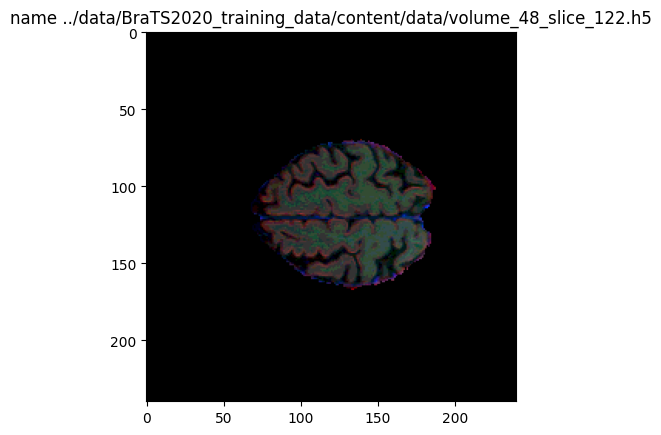

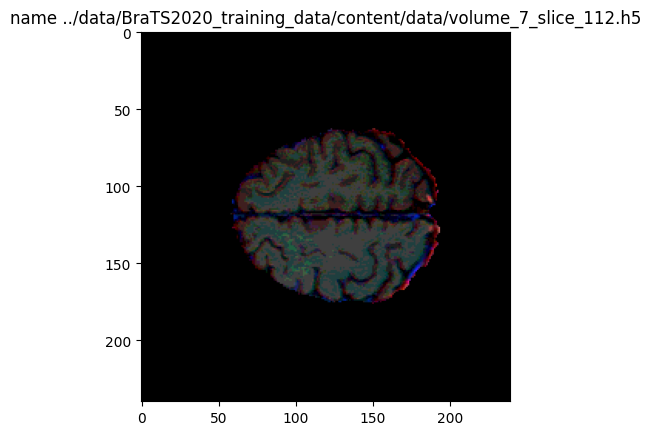

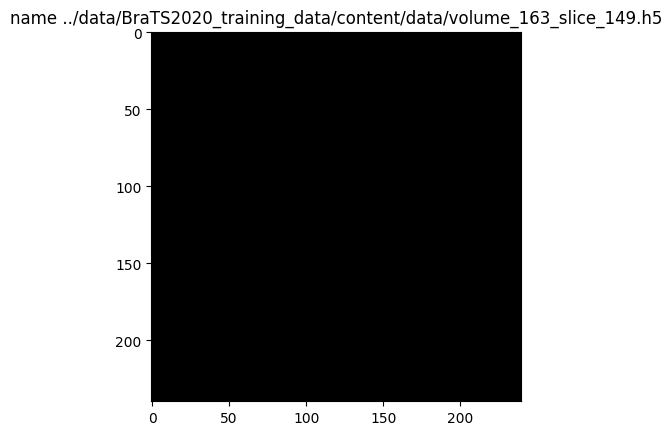

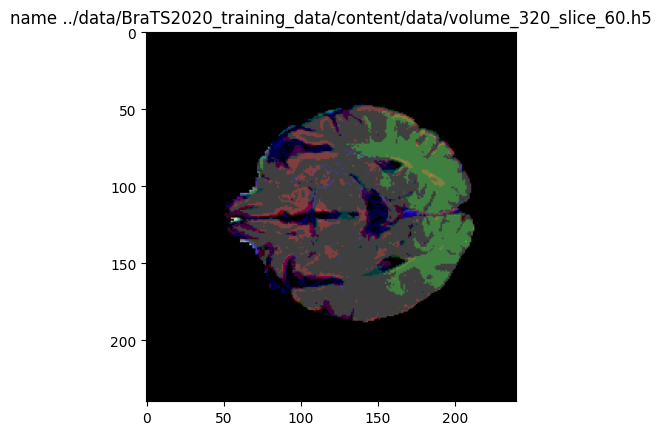

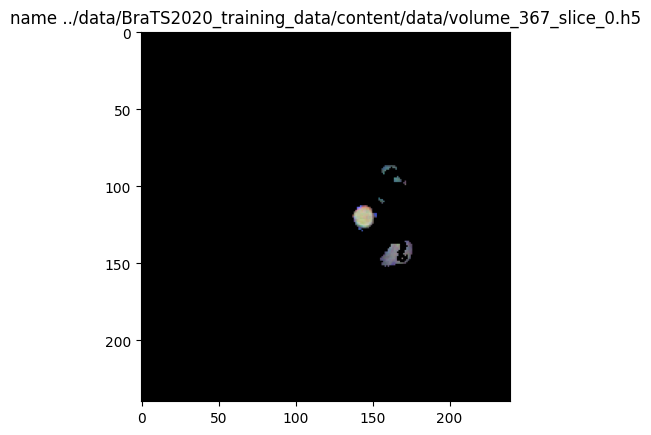

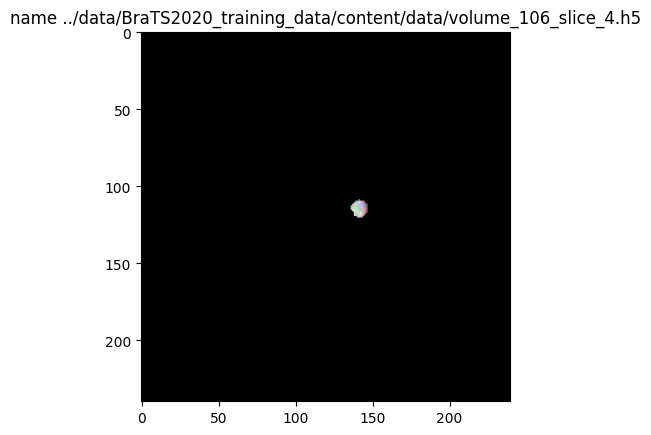

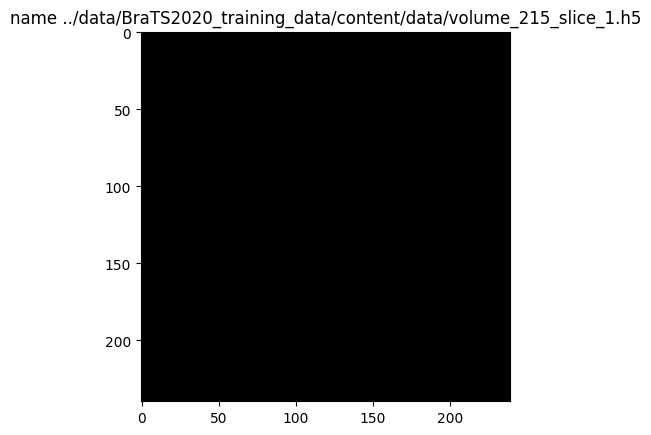

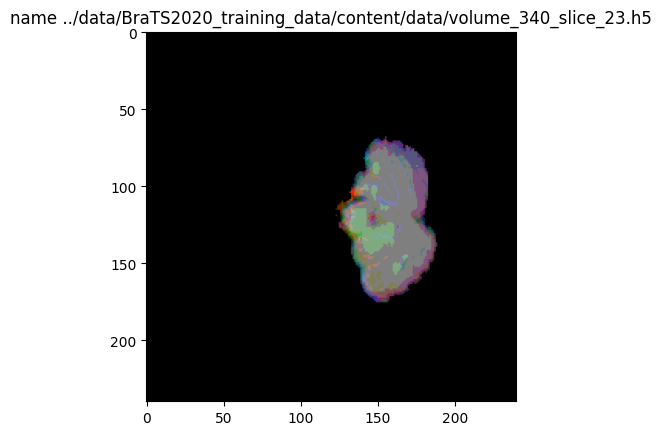

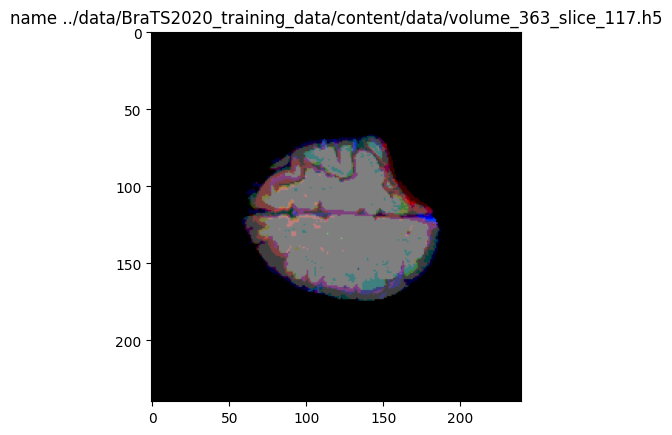

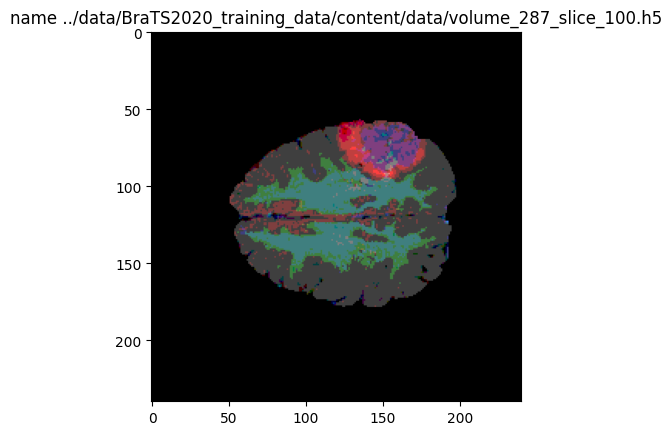

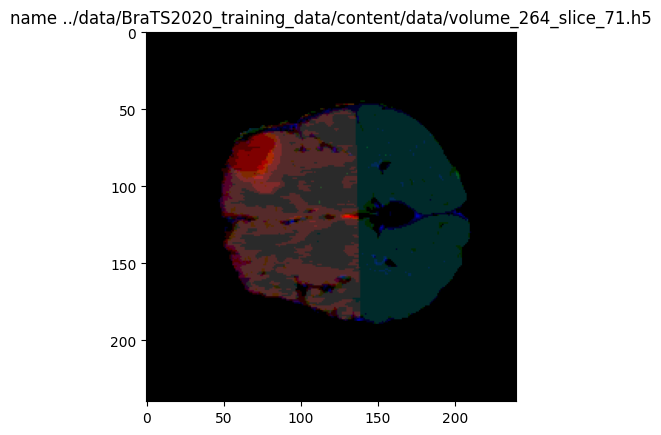

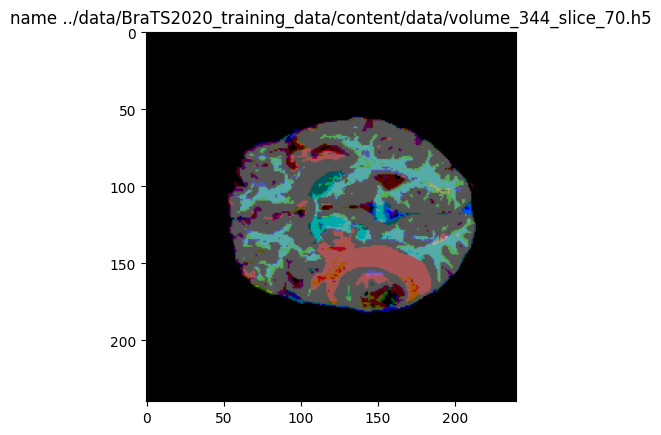

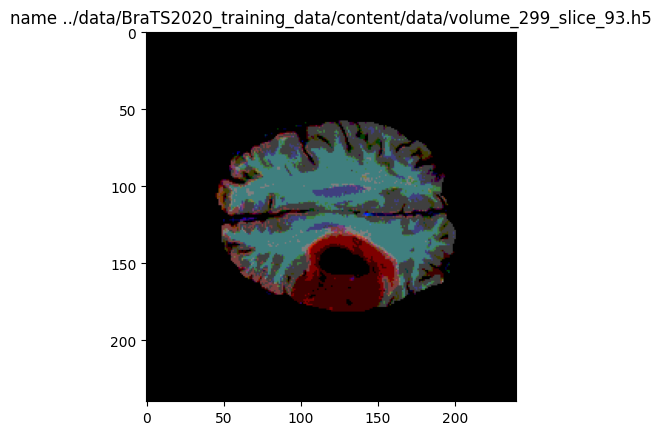

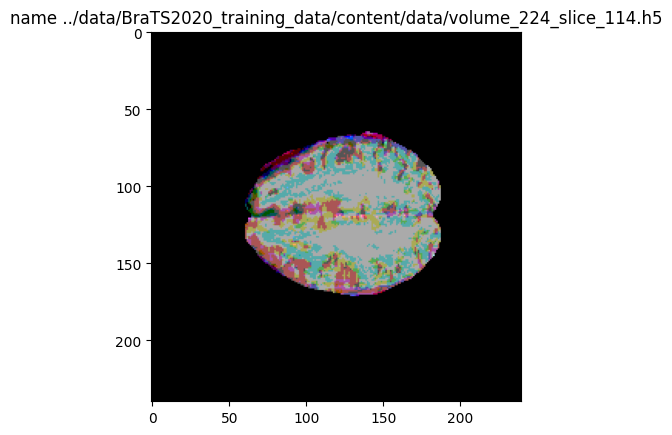

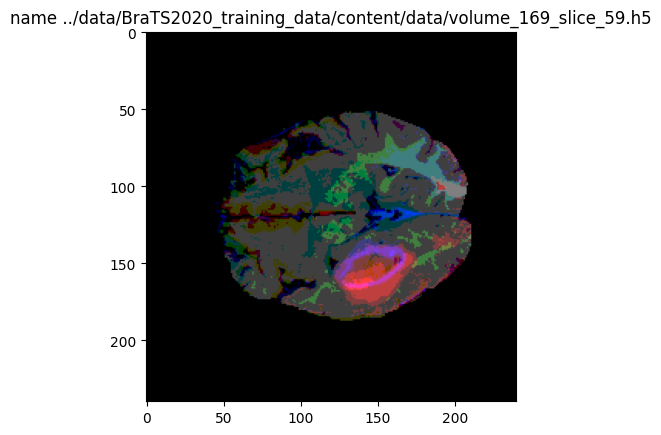

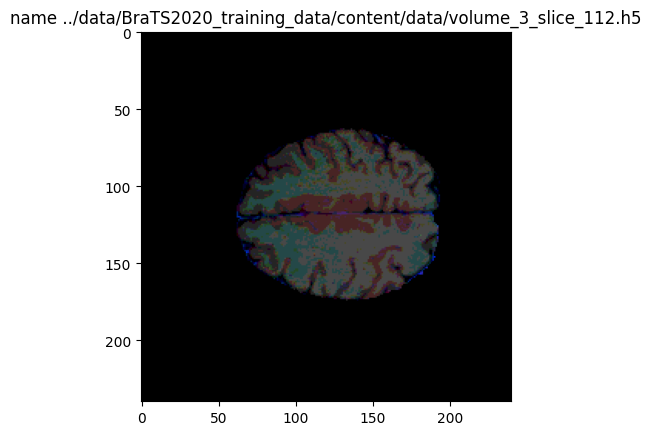

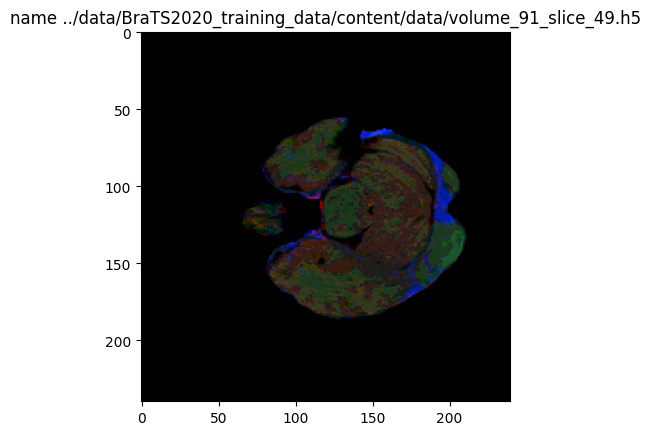

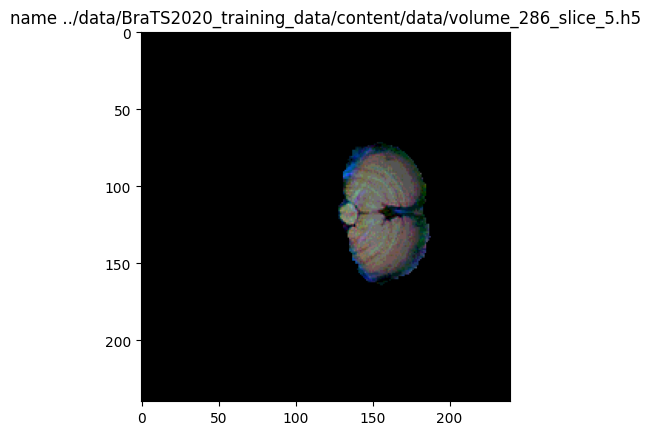

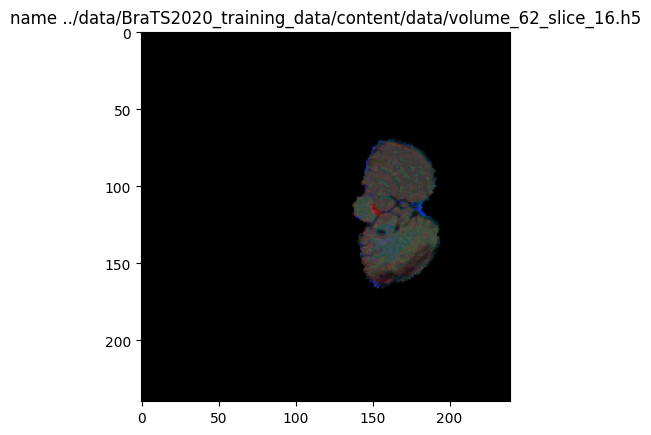

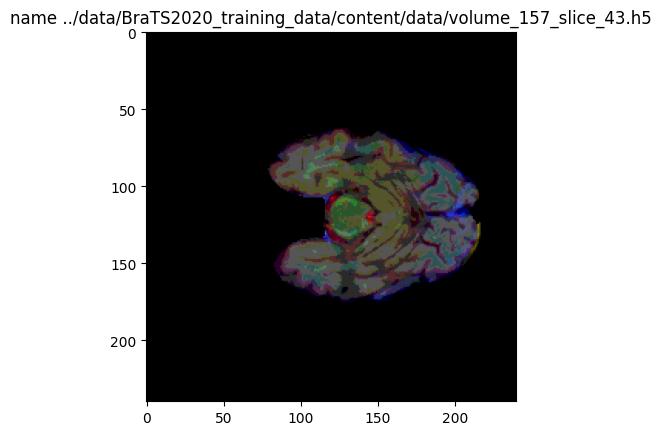

In [4]:
etal_class_list = []

fig, axs  = plt.subplots(num_of_test_data, 1, figsize=(10, 21*num_of_test_data))
for i in range(len(test_imgs)): #imgs, classes in test_data:
    imgs, classes = test_data[i]
    etal_class_list.append(int(classes[0].item()))

    img = imgs[0].permute(1, 2, 0).numpy()
    
    img = img[:,:,:3].astype(int)
    minv = img.min()
    maxv = img.max()
    img = (img - minv)/(maxv-minv) *255 if img.max() != img.min() else img
    
    axs[i].set_title(f"name {test_imgs[i]}")
    axs[i].imshow(img.astype(np.uint8))
    
print(f"classes {etal_class_list}\n")

In [5]:
model_vgg = Custom_VGG(ipt_size=(240, 240, 4), pretrained=False)
model_vgg.load_state_dict(torch.load("model_vgg_11.pth"))

model_resnet = Custom_ResNet(ipt_size=(240, 240, 4), pretrained=False)
model_resnet.load_state_dict(torch.load("model_resnet.pth"))

model_efficientnet = Custom_EfficientNet(ipt_size=(240, 240, 4), pretrained=False)
model_efficientnet.load_state_dict(torch.load("model_efficientnet.pth"))

model_densenet = Custom_DenseNet(ipt_size=(240, 240, 4), pretrained=False)
model_densenet.load_state_dict(torch.load("model_densenet.pth"))

<All keys matched successfully>

In [7]:
accuracy_model_vgg, outpit_vgg = get_accuracy_with_output(test_data, model_vgg, device="cpu")
accuracy_model_resnet, outpit_resnet = get_accuracy_with_output(test_data, model_resnet, device="cpu")
accuracy_model_efficientnet, outpit_efficientnet = get_accuracy_with_output(test_data, model_efficientnet, device="cpu")
accuracy_model_densenet, outpit_densenet = get_accuracy_with_output(test_data, model_densenet, device="cpu")

names = [
    "model_vgg\t\t",
    "model_resnet\t\t",
    "model_efficientnet\t",
    "model_densenet\t\t"
]

outputs = [
    outpit_vgg,
    outpit_resnet,
    outpit_efficientnet,
    outpit_densenet    
]

result = [
    accuracy_model_vgg,
    accuracy_model_resnet,
    accuracy_model_efficientnet,
    accuracy_model_densenet
]

In [8]:
threshold = 0.5

for i in range(len(result)): 
    print(f"Accuracy {names[i]} = {result[i].item():.3f},\t full val {np.abs(np.array(outputs[i]))}")

Accuracy 1.0,	 full val [0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0.]
Accuracy 0.95,	 full val [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0.]
Accuracy 1.0,	 full val [0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0.]
Accuracy 0.9,	 full val [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0.]


In [9]:
def Hybrid_solution(outputs):
    hybrid_res = np.array(outputs)
    return hybrid_res.mean(axis=0)

def threshold_val(hybrid_res, threshold):
    hybrid_res[hybrid_res<threshold] = 0
    hybrid_res[hybrid_res>0] = 1

    return hybrid_res.astype(int)
    

In [10]:
hybrid_res = Hybrid_solution(outputs)
print(f"Hibrid result {hybrid_res}")
print(f"True result {etal_class_list}")

n = len(etal_class_list)
tp = (np.array(np.round(hybrid_res).astype(int)) == np.array(etal_class_list)).sum()

print(f"Result accuracy {tp / n}")


Hibrid result [0.   0.   0.   0.5  0.   0.   0.   0.   0.   1.   0.75 1.   1.   0.
 1.   0.   0.   0.   0.   0.  ]
True result [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0]
Result accuracy 0.95
